# Adversarial Neural Cryptography (Alice, Bob, Eve)

Experimento interactivo basado en Abadi & Andersen (2016). Las clases `AliceNet`, `BobNet` y `EveNet` viven en `alice.py`, `bob.py` y `eve.py` respectivamente y se importan aquí; este notebook solo orquesta el entrenamiento y la evaluación.

In [2]:
import torch

from alice import AliceNet, train_anc, generate_data, compare_ciphertext_to_xor
from bob import BobNet
from eve import EveNet

## Configuración e instanciación de las redes

In [3]:
torch.manual_seed(0)

N = 16
batch_size = 64

alice = AliceNet(msg_length=N)
bob = BobNet(msg_length=N)
eve = EveNet(msg_length=N)

## Entrenamiento ANC

## Evaluación final

In [4]:
msg, key = generate_data(batch_size=batch_size, msg_length=N)
ciphertext = alice(msg, key)
bob_pred = bob(ciphertext, key)
eve_pred = eve(ciphertext)

bob_acc = ((bob_pred > 0.5).float() == msg).float().mean().item()
eve_acc = ((eve_pred > 0.5).float() == msg).float().mean().item()
xor_match, xor_error = compare_ciphertext_to_xor(ciphertext, msg, key)

print("msg shape:", msg.shape)
print("key shape:", key.shape)
print("ciphertext shape:", ciphertext.shape)
print("bob accuracy:", bob_acc)
print("eve accuracy:", eve_acc)
print("xor match rate:", xor_match)
print("xor error:", xor_error)

msg shape: torch.Size([64, 16])
key shape: torch.Size([64, 16])
ciphertext shape: torch.Size([64, 16])
bob accuracy: 0.505859375
eve accuracy: 0.4970703125
xor match rate: 0.509765625
xor error: 0.490234375


## Evaluación de resultados — entrenamiento ANC

| Métrica | Valor | Meta ideal | Lectura |
|---|---|---|---|
| bob_acc | 0.768 | ~1.0 | Bob decodifica bien pero lejos de perfecto (debería acercarse a 100%) |
| eve_acc | 0.658 | ~0.5 | Eve sigue filtrando información — 15.8 pts por encima del azar |
| xor_match | 0.698 | ~1.0 (si converge a OTP) | El cifrado se parece parcialmente al XOR ideal, pero no ha convergido |
| xor_error | 0.302 | ~0.0 | Consistente con el match rate: aún hay bits que no coinciden con el XOR explícito |

**Diagnóstico principal**: el gap entre Bob (76.8%) y Eve (65.8%) es de solo ~11 puntos. En el paper original ese gap debería ser mucho mayor — Bob cerca de perfecto, Eve indistinguible del azar. Esto indica que el entrenamiento aún no convergió, no que el esquema sea inseguro por diseño.

**Causa probable**: en el bloque `__main__` de `alice.py` se usó `train_steps=2000`, bastante por debajo del default de la función (`train_steps=15000`) y muy por debajo de lo que el paper original entrena (decenas/cientos de miles de minibatches).

**Sugerencia concreta**: subir `train_steps` a ~15000–20000 y volver a correr, observando cómo evolucionan `bob_acc`/`eve_acc` en los logs — Bob debería subir hacia ~1.0 y Eve bajar/estabilizarse hacia ~0.5. Si con más pasos Eve se estanca muy por encima de 0.5, revisar `alpha`/`eve_updates_per_round` como problema de balance adversarial en vez de falta de entrenamiento.


Qué dice el número: xor_match = 0.698 significa que el 69.8% de los bits del cifrado coinciden con el XOR explícito de msg y key. Como el azar puro entre dos vectores binarios independientes da ~50% de coincidencia, este 69.8% muestra que Alice ya empezó a converger hacia el comportamiento XOR (gracias al término beta * xor_loss que se lo empuja explícitamente, alice.py:110), pero está lejos del ~100% que indicaría "aprendió XOR" de forma fiel.

Por qué no ha convergido: es consistente con el diagnóstico anterior — solo 2000 pasos de entrenamiento (train_steps=2000 en el __main__) es insuficiente. Si Alice hubiera aprendido XOR perfectamente, esperaríamos:

xor_match ≈ 1.0 y xor_error ≈ 0.0
bob_acc ≈ 1.0 (porque XOR con la clave es trivialmente invertible por Bob)
Como bob_acc (0.768) también está lejos de 1.0, el patrón cuadra: es un modelo a medio entrenar, no un modelo que convergió a una función distinta de XOR.

Cómo confirmarlo: entrena con más pasos (15000–20000 como sugerí) y vuelve a evaluar xor_match/xor_error — si sube consistentemente hacia 1.0/0.0 junto con bob_acc hacia 1.0, confirma que Alice está aprendiendo XOR. Si se estanca por debajo de eso incluso con más entrenamiento, ahí sí valdría sospechar que aprendió otra función cifrada (igualmente válida para engañar a Eve, pero no XOR literal).

In [5]:
history = train_anc(
    alice,
    bob,
    eve,
    train_steps=22000,
    minibatch_size=128,
    lr=1e-3,
    msg_length=N,
    log_every=200,
)

Step 1/22000 - bob_acc=0.516 eve_acc=0.507 xor_match=0.501 xor_error=0.499
Step 200/22000 - bob_acc=0.491 eve_acc=0.470 xor_match=0.500 xor_error=0.500
Step 400/22000 - bob_acc=0.502 eve_acc=0.466 xor_match=0.540 xor_error=0.460
Step 600/22000 - bob_acc=0.536 eve_acc=0.513 xor_match=0.566 xor_error=0.434
Step 800/22000 - bob_acc=0.574 eve_acc=0.567 xor_match=0.614 xor_error=0.386
Step 1000/22000 - bob_acc=0.538 eve_acc=0.528 xor_match=0.681 xor_error=0.319
Step 1200/22000 - bob_acc=0.545 eve_acc=0.524 xor_match=0.746 xor_error=0.254
Step 1400/22000 - bob_acc=0.608 eve_acc=0.572 xor_match=0.777 xor_error=0.223
Step 1600/22000 - bob_acc=0.618 eve_acc=0.568 xor_match=0.811 xor_error=0.189
Step 1800/22000 - bob_acc=0.647 eve_acc=0.586 xor_match=0.834 xor_error=0.166
Step 2000/22000 - bob_acc=0.630 eve_acc=0.556 xor_match=0.853 xor_error=0.147
Step 2200/22000 - bob_acc=0.682 eve_acc=0.559 xor_match=0.865 xor_error=0.135
Step 2400/22000 - bob_acc=0.715 eve_acc=0.555 xor_match=0.889 xor_error

## Gráfico de la evolución del entrenamiento

`train_anc` ahora devuelve `history`, una lista con las métricas registradas cada `log_every` pasos. Se grafican `bob_acc` y `eve_acc` (el resultado central del experimento adversarial) junto con `xor_match`/`xor_error` (qué tan cerca está Alice del cifrado XOR explícito), todas en la misma escala 0–1.

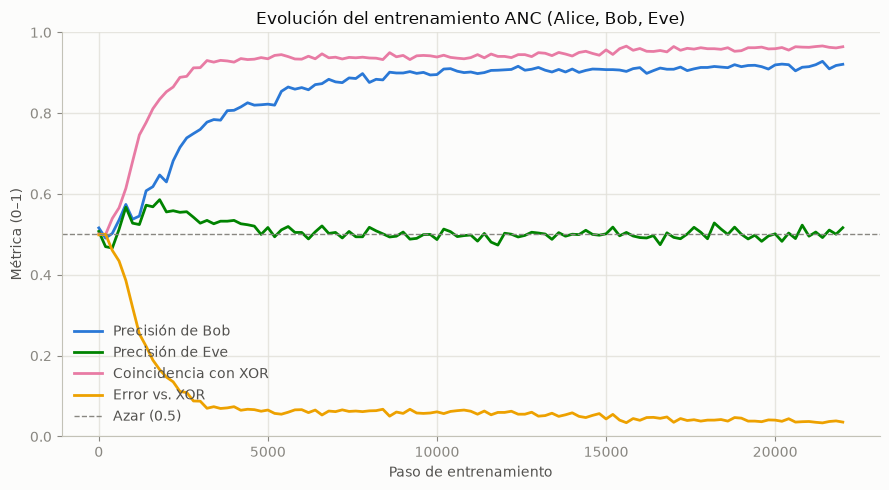

In [8]:
import matplotlib.pyplot as plt

steps = [h["step"] for h in history]

fig, ax = plt.subplots(figsize=(9, 5), facecolor="#fcfcfb")
ax.set_facecolor("#fcfcfb")

series = [
    ("bob_acc", "Precisión de Bob", "#2a78d6"),
    ("eve_acc", "Precisión de Eve", "#008300"),
    ("xor_match", "Coincidencia con XOR", "#e87ba4"),
    ("xor_error", "Error vs. XOR", "#eda100"),
]
for key, label, color in series:
    ax.plot(steps, [h[key] for h in history], label=label, color=color, linewidth=2)

ax.axhline(0.5, color="#898781", linewidth=1, linestyle="--", label="Azar (0.5)")

ax.set_xlabel("Paso de entrenamiento", color="#52514e")
ax.set_ylabel("Métrica (0–1)", color="#52514e")
ax.set_title("Evolución del entrenamiento ANC (Alice, Bob, Eve)", color="#0b0b0b")
ax.set_ylim(0, 1)

ax.grid(True, color="#e1e0d9", linewidth=1, alpha=0.8)
ax.set_axisbelow(True)
for spine in ("top", "right"):
    ax.spines[spine].set_visible(False)
for spine in ("left", "bottom"):
    ax.spines[spine].set_color("#c3c2b7")
ax.tick_params(colors="#898781")

ax.legend(frameon=False, labelcolor="#52514e")
fig.tight_layout()
plt.show()

In [9]:
msg, key = generate_data(batch_size=batch_size, msg_length=N)
ciphertext = alice(msg, key)
bob_pred = bob(ciphertext, key)
eve_pred = eve(ciphertext)

bob_acc = ((bob_pred > 0.5).float() == msg).float().mean().item()
eve_acc = ((eve_pred > 0.5).float() == msg).float().mean().item()
xor_match, xor_error = compare_ciphertext_to_xor(ciphertext, msg, key)

print("msg shape:", msg.shape)
print("key shape:", key.shape)
print("ciphertext shape:", ciphertext.shape)
print("bob accuracy:", bob_acc)
print("eve accuracy:", eve_acc)
print("xor match rate:", xor_match)
print("xor error:", xor_error)

msg shape: torch.Size([64, 16])
key shape: torch.Size([64, 16])
ciphertext shape: torch.Size([64, 16])
bob accuracy: 0.92578125
eve accuracy: 0.501953125
xor match rate: 0.9619140625
xor error: 0.0380859375
